In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [ ]:
загрузка и разделение данных

In [5]:
df = pd.read_csv("cirrhosis.csv")  

X = df.drop(columns=["Status"])
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes:
X_train: (334, 19)
X_test : (84, 19)
y_train: (334,)
y_test : (84,)


In [6]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [7]:
gb_clf_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_clf_baseline.fit(X_train, y_train)

y_pred_base = gb_clf_baseline.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_base, average='weighted', zero_division=0):.4f}")

print(classification_report(y_test, y_pred_base, zero_division=0))


Accuracy : 0.8214
F1-score : 0.8005
              precision    recall  f1-score   support

           C       0.84      0.91      0.88        47
          CL       0.00      0.00      0.00         5
           D       0.81      0.81      0.81        32

    accuracy                           0.82        84
   macro avg       0.55      0.58      0.56        84
weighted avg       0.78      0.82      0.80        84



In [ ]:
неплохой резултат 
попробуем больше гридсерчем

In [11]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0]
}

gb_clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_clf_grid = GridSearchCV(
    gb_clf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

gb_clf_grid.fit(X_train, y_train)

print(gb_clf_grid.best_params_)
print(f"Best CV F1: {gb_clf_grid.best_score_:.4f}")

best_gb_clf = gb_clf_grid.best_estimator_

y_pred_best = best_gb_clf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_best, average='weighted', zero_division=0):.4f}")

print(classification_report(y_test, y_pred_best, zero_division=0))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV F1: 0.8219
Accuracy : 0.8095
F1-score : 0.7933
              precision    recall  f1-score   support

           C       0.83      0.91      0.87        47
          CL       0.00      0.00      0.00         5
           D       0.83      0.78      0.81        32

    accuracy                           0.81        84
   macro avg       0.55      0.57      0.56        84
weighted avg       0.78      0.81      0.79        84



In [ ]:
для cvкласса метрика улучшилачь
Далее своя реализация

In [12]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [ ]:
Decision stump(в качестве слабого алгоритма в градиентном бустингк)
выполняет 1 разбиение по признаку и возвращает числовое значение

In [13]:
class MyDecisionStump:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_features = X.shape[1]
        self.feature = np.random.randint(0, n_features)
        values = X[:, self.feature]
        self.threshold = np.median(values)

        left_idx = values <= self.threshold
        right_idx = values > self.threshold

        self.left_value = np.mean(y[left_idx]) if left_idx.any() else 0.0
        self.right_value = np.mean(y[right_idx]) if right_idx.any() else 0.0

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = []

        for x in X:
            if x[self.feature] <= self.threshold:
                preds.append(self.left_value)
            else:
                preds.append(self.right_value)

        return np.array(preds)


In [ ]:
реализуется градиентный бустинг для классификации на основе логистической функции потерь
предсказание формируется суммой вкладов слабых моделей

In [17]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=50, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.init_value = None
        self.classes_ = None

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        X = np.asarray(X)

        self.classes_ = np.unique(y)
        y_bin = (y == self.classes_[1]).astype(int)

        p = np.mean(y_bin)
        self.init_value = np.log(p / (1 - p))

        F = np.full(len(y), self.init_value)

        for _ in range(self.n_estimators):
            p = self._sigmoid(F)
            residuals = y_bin - p  

            stump = MyDecisionStump()
            stump.fit(X, residuals)

            F += self.learning_rate * stump.predict(X)
            self.models.append(stump)

        return self

    def predict(self, X):
        X = np.asarray(X)
        F = np.full(X.shape[0], self.init_value)

        for stump in self.models:
            F += self.learning_rate * stump.predict(X)

        probs = self._sigmoid(F)
        preds = (probs >= 0.5).astype(int)

        return self.classes_[preds]


In [18]:
from scipy import sparse

X_train_proc = best_gb_clf.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_gb_clf.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [19]:
my_gb = MyGradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1
)

my_gb.fit(X_train_proc, y_train)
y_pred_my = my_gb.predict(X_test_proc)

print(f"Accuracy : {accuracy_score(y_test, y_pred_my):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_my, average='weighted', zero_division=0):.4f}")

print(classification_report(y_test, y_pred_my, zero_division=0))


Accuracy : 0.5595
F1-score : 0.4015
              precision    recall  f1-score   support

           C       0.56      1.00      0.72        47
          CL       0.00      0.00      0.00         5
           D       0.00      0.00      0.00        32

    accuracy                           0.56        84
   macro avg       0.19      0.33      0.24        84
weighted avg       0.31      0.56      0.40        84



In [ ]:
Неплохо, попробуем улучшить

In [ ]:
stump перебирает несколько признаков и выбирает лучшее разбиение по mse

In [23]:
class MyDecisionStumpImproved:
    def __init__(self, n_features_try=5):
        self.feature = None
        self.threshold = None
        self.left_value = None
        self.right_value = None
        self.n_features_try = n_features_try

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape
        features = np.random.choice(n_features, self.n_features_try, replace=False)

        best_mse = np.inf

        for f in features:
            values = X[:, f]
            threshold = np.median(values)

            left = values <= threshold
            right = values > threshold

            if left.sum() == 0 or right.sum() == 0:
                continue

            left_val = np.mean(y[left])
            right_val = np.mean(y[right])

            mse = (
                np.mean((y[left] - left_val) ** 2) +
                np.mean((y[right] - right_val) ** 2)
            )

            if mse < best_mse:
                best_mse = mse
                self.feature = f
                self.threshold = threshold
                self.left_value = left_val
                self.right_value = right_val

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = np.where(
            X[:, self.feature] <= self.threshold,
            self.left_value,
            self.right_value
        )
        return preds


In [24]:
class MyGradientBoostingClassifierV2:
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = {}
        self.init_values = {}
        self.classes_ = None

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        X = np.asarray(X)
        self.classes_ = np.unique(y)

        for cls in self.classes_:
            y_bin = (y == cls).astype(int)

            p = np.mean(y_bin)
            self.init_values[cls] = np.log((p + 1e-6) / (1 - p + 1e-6))
            F = np.full(len(y), self.init_values[cls])

            models_cls = []

            for _ in range(self.n_estimators):
                p_hat = self._sigmoid(F)
                residuals = y_bin - p_hat

                stump = MyDecisionStumpImproved()
                stump.fit(X, residuals)

                F += self.learning_rate * stump.predict(X)
                models_cls.append(stump)

            self.models[cls] = models_cls

        return self

    def predict(self, X):
        X = np.asarray(X)
        scores = []

        for cls in self.classes_:
            F = np.full(X.shape[0], self.init_values[cls])
            for stump in self.models[cls]:
                F += self.learning_rate * stump.predict(X)
            scores.append(F)

        scores = np.vstack(scores).T
        return self.classes_[np.argmax(scores, axis=1)]


In [ ]:
для каждого класса обучается отдельный градиентный бустинг
финальное предсказание класс с максимальным скором


In [26]:
my_gb_v2 = MyGradientBoostingClassifierV2(
    n_estimators=100,
    learning_rate=0.1
)

my_gb_v2.fit(X_train_proc, y_train)
y_pred_my_v2 = my_gb_v2.predict(X_test_proc)

print(f"Accuracy : {accuracy_score(y_test, y_pred_my_v2):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_my_v2, average='weighted', zero_division=0):.4f}")

print(classification_report(y_test, y_pred_my_v2, zero_division=0))


Accuracy : 0.6786
F1-score : 0.6292
              precision    recall  f1-score   support

           C       0.64      0.96      0.77        47
          CL       0.00      0.00      0.00         5
           D       0.86      0.38      0.52        32

    accuracy                           0.68        84
   macro avg       0.50      0.44      0.43        84
weighted avg       0.69      0.68      0.63        84



In [ ]:
сравнение

,Model,F1-score (weighted)
0,Gradient Boosting базовый,0.800534
1,Gradient Boosting базовый улучшенный,0.793271
2,My Gradient Boosting,0.401490
3,My Gradient Boosting улучшенный,0.629161


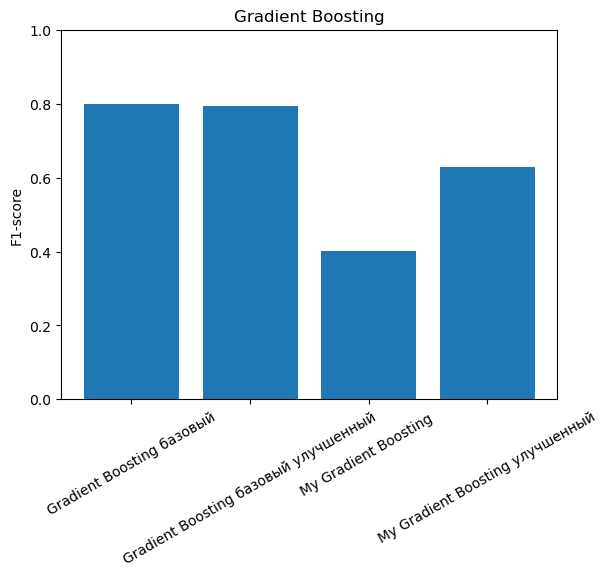

In [28]:
results_gb = pd.DataFrame({
    "Model": [
        "Gradient Boosting базовый",
        "Gradient Boosting базовый улучшенный",
        "My Gradient Boosting ",
        "My Gradient Boosting улучшенный"
    ],
    "F1-score (weighted)": [
        f1_score(y_test, y_pred_base, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_best, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_my, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_my_v2, average="weighted", zero_division=0)
    ]
})

display(results_gb)

# График
plt.figure()
plt.bar(results_gb["Model"], results_gb["F1-score (weighted)"])
plt.title("Gradient Boosting")
plt.ylabel("F1-score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


In [ ]:
Далее Регрессия

In [ ]:
загрузка и разделение данных

In [30]:
df = pd.read_csv("mobile.csv")  

X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes:
X_train: (668, 9)
X_test : (168, 9)
y_train: (668,)
y_test : (168,)


In [37]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
базовая модель

In [65]:
gb_reg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_reg_baseline.fit(X_train, y_train)
y_pred_base = gb_reg_baseline.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_base):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_base):.4f}")


MAE: 4051.60
MSE: 91627998.52
R2 : 0.9606


In [ ]:
хороший результат, улучшим

In [41]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0]
}

gb_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_reg_grid = GridSearchCV(
    gb_reg_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

gb_reg_grid.fit(X_train, y_train)

print(gb_reg_grid.best_params_)
print(f"Best CV R2: {gb_reg_grid.best_score_:.4f}")

best_gb_reg = gb_reg_grid.best_estimator_

y_pred_best = best_gb_reg.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_best):.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 1.0}
Best CV R2: 0.6492
MAE: 2950.08
MSE: 74573634.18
R2 : 0.9679


In [ ]:
улучшено, далее своя реализация

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
слабая модел, 1 разбиение по признаку

In [42]:
class MyDecisionStumpRegressor:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_features = X.shape[1]
        self.feature = np.random.randint(0, n_features)
        values = X[:, self.feature]
        self.threshold = np.median(values)

        left = values <= self.threshold
        right = values > self.threshold

        self.left_value = np.mean(y[left]) if left.any() else 0.0
        self.right_value = np.mean(y[right]) if right.any() else 0.0
        return self

    def predict(self, X):
        X = np.asarray(X)
        return np.where(
            X[:, self.feature] <= self.threshold,
            self.left_value,
            self.right_value
        )


In [ ]:
свой градиентный бустинг с mse

In [43]:
class MyGradientBoostingRegressor:
    def __init__(self, n_estimators=50, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.init_value = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.init_value = np.mean(y)
        F = np.full(len(y), self.init_value)

        for _ in range(self.n_estimators):
            residuals = y - F

            stump = MyDecisionStumpRegressor()
            stump.fit(X, residuals)

            F += self.learning_rate * stump.predict(X)
            self.models.append(stump)

        return self

    def predict(self, X):
        X = np.asarray(X)
        F = np.full(X.shape[0], self.init_value)

        for stump in self.models:
            F += self.learning_rate * stump.predict(X)

        return F


In [44]:
from scipy import sparse

X_train_proc = best_gb_reg.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_gb_reg.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [46]:
my_gb_reg = MyGradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1
)

my_gb_reg.fit(X_train_proc, y_train)
y_pred_my = my_gb_reg.predict(X_test_proc)

print(f"MAE: {mean_absolute_error(y_test, y_pred_my):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_my):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_my):.4f}")


MAE: 19854.44
MSE: 2284365966.25
R2 : 0.0175


In [ ]:
результат не очень, пробуем улучшить

In [ ]:
перебирает несколько случайно выбраных признаков и 
использует медианe признака в качестве порога разбиения
для каждого разбиения вычисляется mse и выбирается разбиение с мин ошибкой

In [59]:
class MyDecisionStumpRegressorV2:
    def __init__(self, n_features_try=5):
        self.feature = None
        self.threshold = None
        self.left_value = None
        self.right_value = None
        self.n_features_try = n_features_try

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape
        features = np.random.choice(
            n_features,
            size=min(self.n_features_try, n_features),
            replace=False
        )

        best_mse = np.inf

        for f in features:
            values = X[:, f]
            threshold = np.median(values)

            left = values <= threshold
            right = values > threshold

            if left.sum() == 0 or right.sum() == 0:
                continue

            left_val = np.mean(y[left])
            right_val = np.mean(y[right])

            mse = (
                np.mean((y[left] - left_val) ** 2) +
                np.mean((y[right] - right_val) ** 2)
            )

            if mse < best_mse:
                best_mse = mse
                self.feature = f
                self.threshold = threshold
                self.left_value = left_val
                self.right_value = right_val

        return self

    def predict(self, X):
        X = np.asarray(X)
        return np.where(
            X[:, self.feature] <= self.threshold,
            self.left_value,
            self.right_value
        )


In [ ]:
n_estimators определяет кол-во слабых моделей, 
learning_rate вклад каждой модели в итоговое предсказание

In [60]:
class MyGradientBoostingRegressorV2:
    def __init__(self, n_estimators=200, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.init_value = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.init_value = np.mean(y)
        F = np.full(len(y), self.init_value)

        for _ in range(self.n_estimators):
            residuals = y - F

            stump = MyDecisionStumpRegressorV2()
            stump.fit(X, residuals)

            F += self.learning_rate * stump.predict(X)
            self.models.append(stump)

        return self

    def predict(self, X):
        X = np.asarray(X)
        F = np.full(X.shape[0], self.init_value)

        for stump in self.models:
            F += self.learning_rate * stump.predict(X)

        return F


In [62]:
my_gb_reg_v2 = MyGradientBoostingRegressorV2(
    n_estimators=200,
    learning_rate=0.1
)

my_gb_reg_v2.fit(X_train_proc, y_train)
y_pred_my_v2 = my_gb_reg_v2.predict(X_test_proc)

print(f"MAE: {mean_absolute_error(y_test, y_pred_my_v2):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_my_v2):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_my_v2):.4f}")


MAE: 17689.61
MSE: 1325933816.61
R2 : 0.4297


In [ ]:
далее cравнение

,Model,R2
0,Gradient Boosting базовая,0.960590
1,Gradient Boosting базовая улучшенная,0.967925
2,My Gradient Boosting,0.017466
3,My Gradient Boosting улучшенный,0.429699


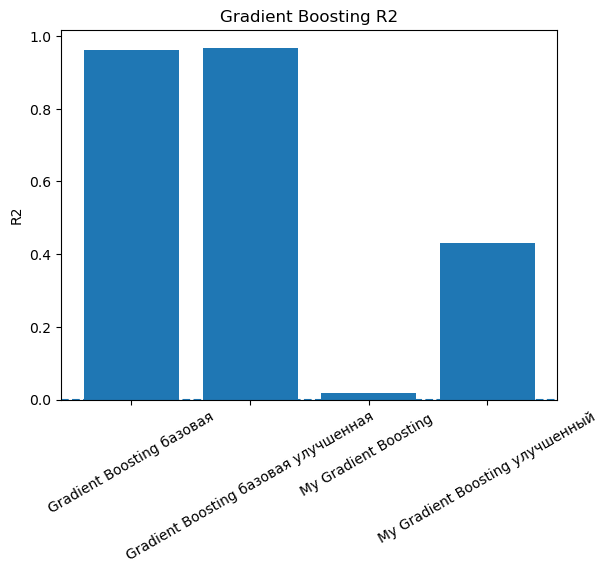

In [64]:
results_gb_reg = pd.DataFrame({
    "Model": [
        "Gradient Boosting базовая",
        "Gradient Boosting базовая улучшенная",
        "My Gradient Boosting ",
        "My Gradient Boosting улучшенный"
    ],
    "R2": [
        r2_score(y_test, y_pred_base),
        r2_score(y_test, y_pred_best),
        r2_score(y_test, y_pred_my),
        r2_score(y_test, y_pred_my_v2)
    ]
})

display(results_gb_reg)

plt.figure()
plt.bar(results_gb_reg["Model"], results_gb_reg["R2"])
plt.title("Gradient Boosting R2")
plt.ylabel("R2")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=30)
plt.show()


In [ ]:
Выводы:
cтоило в самом начале выбрать датасет для классификации более сбалансированный,
а то класс cl плохо угадывается  